In [1]:
# ------------ IMPORTS ------------

import torch
import numpy as np
import pandas as pd
from torch import nn
import torch
print("cuda available:", torch.cuda.is_available())
print("imported torch")
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
print("imported tokeniser")
from sklearn.metrics import f1_score, classification_report
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from datasets import Dataset
print("cuda" if torch.cuda.is_available() else "cpu")
import sys
import os
# !git clone https://github.com/Tisya-V/NLP-CW.git
# sys.path.insert(0, "/content/NLP-CW/src")

import utils

!nvidia-smi

cuda available: True
imported torch
imported tokeniser
cuda
Wed Mar  4 18:04:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080        Off |   00000000:2D:00.0  On |                  N/A |
|  0%   33C    P8              9W /  320W |     101MiB /  16376MiB |      0%      Default |
|                                         |                        |            

In [4]:
# ------------ LOAD AND AUGMENT DATA ------------

RANDOM_SEED = 47

train_df, dev_df, dev_kept, dev_oglen, test_df, test_kept, test_oglen = utils.load_and_clean_data()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["binary_label"],  # ensures same class ratio in both splits
    random_state=RANDOM_SEED
)
# !pip install nlpaug nltk
import nlpaug.augmenter.word as naw

# Synonym replacement: replace up to 15% of words, max 3 swaps per sentence
sr_aug = naw.SynonymAug(
    aug_src='wordnet',
    aug_p=0.15,
    aug_max=3
)

def augment_pcl_rows(df, augmenter, n_copies=3, seed=RANDOM_SEED):
    pcl_rows = df[df["binary_label"] == 1].copy()
    augmented = []
    for _, row in pcl_rows.iterrows():
        for _ in range(n_copies):
            try:
                new_text = augmenter.augment(row["text"])[0]
            except Exception:
                new_text = row["text"]  # fallback: keep original if augmentation fails
            augmented.append({"text": new_text, "binary_label": 1})
    return pd.DataFrame(augmented)

aug_df = augment_pcl_rows(train_df, sr_aug, n_copies=0)
train_df_aug = pd.concat([train_df, aug_df], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

print(f"Original: {train_df['binary_label'].value_counts().to_dict()}")
print(f"Augmented: {train_df_aug['binary_label'].value_counts().to_dict()}")

Data loaded successfully
Train: 8375 | Dev: 2094 | Test: 3832
train: 0 NaN | 0 empty | 1 <3 words
Short rows (<3 words):      par_id      text  binary_label
1620   1657  refugees             0
dev: 1 NaN | 0 empty | 1 <3 words
Short rows (<3 words):     par_id              text  binary_label
794   9064  Feeling hopeless             0
  Dropping 1 rows:
    par_id text
401   8640  NaN
test: 0 NaN | 0 empty | 0 <3 words
Original: {0: 6443, 1: 675}
Augmented: {0: 6443, 1: 675}


In [7]:
# ------------ TOKENISE ------------

MODEL_NAME = "roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize(df):
    enc = tokenizer(
        df["text"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=256,
    )
    if "binary_label" in df.columns:
        enc["labels"] = df["binary_label"].tolist()
    return Dataset.from_dict(enc)

train_dataset = tokenize(train_df_aug)
val_dataset   = tokenize(val_df)
dev_dataset   = tokenize(dev_df)

In [ ]:
# ------------ COMPUTE CLASS WEIGHTS ------------

labels_array = train_df["binary_label"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=labels_array
)
print(f"Class weights → 0: {class_weights[0]:.3f}, 1: {class_weights[1]:.3f}")

# Move to device for use in loss
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
device = torch.device(device)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

Class weights → 0: 0.552, 1: 5.273
Device: cuda


Class weights → 0: 0.552, 1: 5.273
Device: cuda


In [ ]:
# ------------ WEIGHTED LOSS TRAINER ------------

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.dtype))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
# ------------ F1 SCORE METRIC ------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # F1 of positive class only — matches the task metric
    f1 = f1_score(labels, preds, pos_label=1)
    return {"f1_pcl": f1}



In [ ]:
# # ------------ HYP TUNING SEARCH ------------

# from itertools import product
# from scipy.special import softmax


# # ── Grid definition ──────────────────────────────────────────────────────────
# param_grid = {
#     "learning_rate"    : [2e-5, 1e-5, 5e-6],
#     "grad_acc_steps"   : [1, 2, 4],
#     "num_train_epochs" : [3, 4, 5],
# }

# keys   = list(param_grid.keys())
# combos = list(product(*param_grid.values()))
# print(f"Total combinations: {len(combos)}")

# # ── Results store ────────────────────────────────────────────────────────────
# results = []

# for i, combo in enumerate(combos):
#     params = dict(zip(keys, combo))
#     print(f"\n▶ Running {i} / {len(combos)}: {params}")

#     model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

#     training_args = TrainingArguments(
#         output_dir                  = "./model",
#         num_train_epochs            = params["num_train_epochs"],
#         per_device_train_batch_size = 8,
#         gradient_accumulation_steps = params["grad_acc_steps"],
#         per_device_eval_batch_size  = 32,
#         learning_rate               = params["learning_rate"],
#         warmup_ratio                = 0.1,
#         weight_decay                = 0.01,
#         eval_strategy               = "epoch",
#         save_strategy               = "no",          # don't save every sweep run
#         load_best_model_at_end      = False,         # manual best tracking below
#         bf16                        = False,
#         fp16                        = False,
#     )

#     trainer = WeightedTrainer(
#         model           = model,
#         args            = training_args,
#         train_dataset   = train_dataset,
#         eval_dataset    = val_dataset,
#         compute_metrics = compute_metrics,
#     )

#     trainer.train()

#     # ── Threshold tuning on val for this config ───────────────────────────
#     val_out      = trainer.predict(val_dataset)
#     val_probs    = softmax(val_out.predictions, axis=-1)[:, 1]
#     val_labels   = val_df["binary_label"].values

#     best_t, best_f1 = 0.5, 0.0
#     for t in np.linspace(0.05, 0.95, 91):
#         preds = (val_probs >= t).astype(int)
#         f1    = f1_score(val_labels, preds, pos_label=1)
#         if f1 > best_f1:
#             best_f1, best_t = f1, t

#     results.append({**params, "val_f1": best_f1, "best_thresh": best_t})
#     print(f"   Val F1: {best_f1:.4f}  |  Threshold: {best_t:.2f}")

#     # Free GPU memory between runs
#     del model, trainer
#     torch.cuda.empty_cache()

# # ── Summary ───────────────────────────────────────────────────────────────────
# results_df = pd.DataFrame(results).sort_values("val_f1", ascending=False)
# print("\n── Sweep Results ──")
# print(results_df.to_string(index=False))


In [ ]:
# ------------ (RE)TRAIN BEST MODEL ------------

# Get from hyp tuning search
# best = results_df.iloc[0]
# print(f"\nBest config: LR={best.learning_rate}, epochs={best.num_train_epochs}, "
#       f"grad_acc_steps={best.grad_acc_steps}, F1={best.val_f1:.4f}, thresh={best.best_thresh:.2f}")

best = {
    "learning_rate": 1e-5,
    "grad_acc_steps": 1,
    "num_train_epochs": 4,
}

# Retrain on full train_df_aug with best params + load best epoch checkpoint
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
training_args = TrainingArguments(
    output_dir                   = "./model_best",
    num_train_epochs             = int(best["num_train_epochs"]),
    per_device_train_batch_size  = 16,
    gradient_accumulation_steps  = int(best["grad_acc_steps"]),
    per_device_eval_batch_size   = 32,
    learning_rate                = best["learning_rate"],
    warmup_ratio                 = 0.1,
    weight_decay                 = 0.01,
    eval_strategy                = "epoch",
    save_strategy                = "epoch",
    metric_for_best_model        = "f1_pcl",
    load_best_model_at_end       = True,
    bf16                         = False,
    fp16                         = False,
    report_to                    = "none",
)
trainer = WeightedTrainer(
    model=model, 
    args=training_args,
    train_dataset=train_dataset, 
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,

)

trainer.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Pcl
1,0.463984,0.535897,0.383659
2,0.241741,0.671411,0.502646
3,0.140449,1.110109,0.546713
4,0.080688,1.383015,0.560311


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2120, training_loss=0.22241128480659342, metrics={'train_runtime': 356.6089, 'train_samples_per_second': 94.984, 'train_steps_per_second': 5.945, 'total_flos': 4456048833576960.0, 'train_loss': 0.22241128480659342, 'epoch': 4.0})

In [25]:
# ------------ FINAL PREDICTIONS ------------
from scipy.special import softmax
# sweep
val_out      = trainer.predict(val_dataset)
val_probs    = softmax(val_out.predictions, axis=-1)[:, 1]
val_labels   = val_df["binary_label"].values

best_t, best_f1 = 0.5, 0.0
for t in np.linspace(0.05, 0.95, 91):
    preds = (val_probs >= t).astype(int)
    f1    = f1_score(val_labels, preds, pos_label=1)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"best thresh: {best_t} with f1: {best_f1}")

def get_predictions(trainer, dataset, threshold = 0.5):
    preds_output = trainer.predict(dataset)
    logits = preds_output.predictions
    probs = softmax(logits, axis=1)[:, 1]
    preds = (probs >= threshold).astype(int)
    return preds

def realign_predictions(preds, kept_indices, original_len, default=0):
    full = np.full(original_len, default, dtype=int)
    for pred, idx in zip(preds, kept_indices):
        full[idx] = pred
    return full

# Dev predictions
dev_preds = get_predictions(trainer, dev_dataset, threshold = best_t)
dev_preds_aligned  = realign_predictions(dev_preds,  dev_kept,  dev_oglen)
print(classification_report(dev_df["binary_label"].values, dev_preds, target_names=["No PCL", "PCL"]))
f1_pos = f1_score(dev_df["binary_label"].values, dev_preds, pos_label=1)
print(f"DEV F1 SCORE: {f1_pos:.4f}")
np.savetxt("dev.txt", dev_preds_aligned.astype(int), fmt="%d")

# Test predictions (no labels)
test_dataset = tokenize(test_df)
test_preds = get_predictions(trainer, test_dataset, threshold = best_t)
test_preds_aligned = realign_predictions(test_preds, test_kept, test_oglen)
np.savetxt("test.txt", test_preds_aligned.astype(int), fmt="%d")

print(f"dev.txt:  {len(dev_preds_aligned)} lines (expected {dev_oglen})")
print(f"test.txt: {len(test_preds_aligned)} lines (expected {test_oglen})")


best thresh: 0.9199999999999999 with f1: 0.5774058577405857


              precision    recall  f1-score   support

      No PCL       0.96      0.96      0.96      1894
         PCL       0.61      0.60      0.61       199

    accuracy                           0.93      2093
   macro avg       0.79      0.78      0.78      2093
weighted avg       0.93      0.93      0.93      2093

DEV F1 SCORE: 0.6076


dev.txt:  2094 lines (expected 2094)
test.txt: 3832 lines (expected 3832)


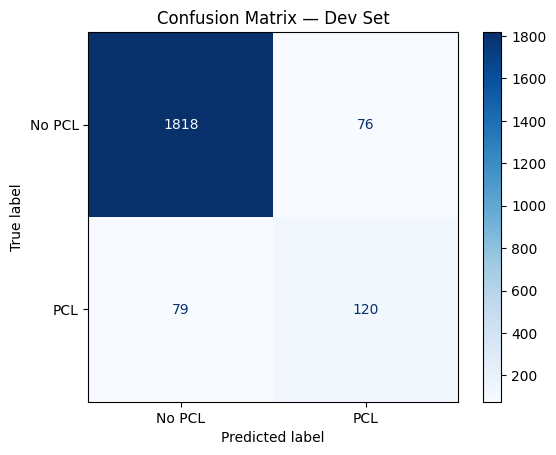

TN: 1818  FP: 76  FN: 79  TP: 120
FP rate (of all No-PCL): 4.0%
FN rate (of all PCL):    39.7%


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(dev_df["binary_label"].values, dev_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No PCL", "PCL"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Dev Set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp_n, fn_n, tp = cm.ravel()
print(f"TN: {tn}  FP: {fp_n}  FN: {fn_n}  TP: {tp}")
print(f"FP rate (of all No-PCL): {fp_n/(tn+fp_n)*100:.1f}%")
print(f"FN rate (of all PCL):    {fn_n/(fn_n+tp)*100:.1f}%")
